# Task 4 – Additive Gaussian Noise

For a subset of **100 samples** add white Gaussian noise calibrated to a target SNR
and compare system performance with Task 1 (no noise).

SNR levels tested: **40 dB** (barely audible), **20 dB** (noticeable), **10 dB** (heavy noise).

**Formula:**
```
P_signal = mean(x²)
P_noise  = P_signal / 10^(SNR_dB / 10)
noise    ~ N(0, sqrt(P_noise))
x_noisy  = x + noise
```

**Prerequisites:** `task1_baseline.ipynb` must have been run (`results/task1_results.json` exists).

## 0. Setup

In [1]:
import sys, json, random
from pathlib import Path

SRC = Path("../src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import torch
import matplotlib.pyplot as plt

from config import cfg
from embeddings import load_model, load_audio
from database import get_collection, list_enrolled
from threshold import compute_eer, compute_metrics_at_threshold, _load_enrolled_embeddings_bulk

RESULTS_DIR = cfg.paths.results_dir
TEST_DIR    = cfg.paths.test_dir
RANDOM_SEED = cfg.dataset.random_seed

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_DIR}")

Results → D:\pwr\biometria\lab\voice\results


## 1. Load Task 1 baseline

In [2]:
task1_path = RESULTS_DIR / "task1_results.json"
if not task1_path.exists():
    raise FileNotFoundError("Run task1_baseline.ipynb first to generate task1_results.json")

with open(task1_path) as f:
    task1 = json.load(f)

eer_threshold = task1["eer_threshold"]
print(f"Task 1 baseline:")
print(f"  EER       = {task1['eer_pct']:.2f}%")
print(f"  Accuracy  = {task1['accuracy_at_eer_pct']:.2f}%")
print(f"  Threshold = {eer_threshold:.4f}")

Task 1 baseline:
  EER       = 0.11%
  Accuracy  = 99.89%
  Threshold = 0.3969


## 2. Load model and enrolled embeddings

In [3]:
print("Loading ECAPA-TDNN model...")
model = load_model()

collection   = get_collection()
enrolled_ids = set(list_enrolled(collection))
print(f"Enrolled speakers: {len(enrolled_ids)}")

enrolled_cache: dict[str, np.ndarray] = _load_enrolled_embeddings_bulk(collection)
print(f"Loaded {len(enrolled_cache)} enrolled embeddings.")

if not enrolled_ids:
    raise RuntimeError("No speakers enrolled. Run src/enroll.py first.")

Loading ECAPA-TDNN model...


d:\pwr\biometria\venv\Lib\site-packages\speechbrain\utils\parameter_transfer.py:234: UserWarning: Requested Pretrainer collection using symlinks on Windows. This might not work; see `LocalStrategy` documentation. Consider unsetting `collect_in` in Pretrainer to avoid symlinking altogether.
  warnings.warn(
Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


Enrolled speakers: 140
Loaded 140 enrolled embeddings.


## 3. Select 100 test samples

Build 50 genuine + 50 impostor trials.

In [4]:
N_GENUINE  = 50
N_IMPOSTOR = 50

rng = random.Random(RANDOM_SEED)

speaker_files: dict[str, list[Path]] = {}
for spk_dir in sorted(TEST_DIR.iterdir()):
    if spk_dir.is_dir() and spk_dir.name in enrolled_ids:
        wavs = sorted(spk_dir.rglob("*.wav"))
        if wavs:
            speaker_files[spk_dir.name] = wavs

speaker_ids = sorted(speaker_files.keys())
print(f"Speakers with test files: {len(speaker_ids)}")

genuine_pool = []
for spk_id in speaker_ids:
    for wav in speaker_files[spk_id]:
        genuine_pool.append((wav, spk_id, True))
rng.shuffle(genuine_pool)

impostor_pool = []
for spk_id in speaker_ids:
    other_ids = [s for s in speaker_ids if s != spk_id]
    if not other_ids:
        continue
    for imp_id in rng.sample(other_ids, min(2, len(other_ids))):
        impostor_pool.append((rng.choice(speaker_files[imp_id]), spk_id, False))
rng.shuffle(impostor_pool)

trials = genuine_pool[:N_GENUINE] + impostor_pool[:N_IMPOSTOR]
rng.shuffle(trials)

print(f"Genuine trials:  {sum(1 for t in trials if t[2])}")
print(f"Impostor trials: {sum(1 for t in trials if not t[2])}")
print(f"Total:           {len(trials)}")

Speakers with test files: 140
Genuine trials:  50
Impostor trials: 50
Total:           100


## 4. Gaussian noise function

Noise power is set so that `SNR = 10 * log10(P_signal / P_noise)`.

In [5]:
# (key, label, snr_db)  –  None means no noise (control)
CONDITIONS = [
    ("no_noise", "No noise",  None),
    ("snr_40db", "SNR 40 dB", 40.0),
    ("snr_20db", "SNR 20 dB", 20.0),
    ("snr_10db", "SNR 10 dB", 10.0),
]

rng_noise = torch.Generator()
rng_noise.manual_seed(RANDOM_SEED)


def add_gaussian_noise(waveform: torch.Tensor, snr_db: float) -> torch.Tensor:
    """Add white Gaussian noise to achieve target SNR relative to signal power."""
    signal_power = waveform.pow(2).mean()
    if signal_power < 1e-10:
        return waveform
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = torch.randn(waveform.shape, generator=rng_noise) * noise_power.sqrt()
    return waveform + noise


def embed_waveform(model, waveform: torch.Tensor) -> np.ndarray:
    with torch.no_grad():
        emb = model.encode_batch(waveform)
    emb = emb.squeeze().cpu().numpy().astype(np.float32)
    norm = np.linalg.norm(emb)
    return emb / norm if norm > 0 else emb


print(f"Conditions: {[c[1] for c in CONDITIONS]}")

Conditions: ['No noise', 'SNR 40 dB', 'SNR 20 dB', 'SNR 10 dB']


## 5. Compute scores for all SNR levels

In [6]:
results: dict[str, dict] = {
    key: {"genuine": [], "impostor": []}
    for key, *_ in CONDITIONS
}

audio_cache: dict[Path, torch.Tensor] = {}

def get_cached(path: Path) -> torch.Tensor:
    if path not in audio_cache:
        audio_cache[path] = load_audio(path)
    return audio_cache[path]


print(f"Processing {len(trials)} trials × {len(CONDITIONS)} conditions...")

for i, (wav_path, enrolled_id, is_genuine) in enumerate(trials):
    if enrolled_id not in enrolled_cache:
        print(f"  [warn] {enrolled_id}: no enrolled embedding, skipping")
        continue

    enrolled_emb = enrolled_cache[enrolled_id]
    waveform = get_cached(wav_path)

    for key, label, snr_db in CONDITIONS:
        w = add_gaussian_noise(waveform, snr_db) if snr_db is not None else waveform

        query_emb = embed_waveform(model, w)
        score = float(np.dot(query_emb, enrolled_emb))

        bucket = "genuine" if is_genuine else "impostor"
        results[key][bucket].append(score)

    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{len(trials)}...")

print("Done.")

Processing 100 trials × 4 conditions...
  25/100...
  50/100...
  75/100...
  100/100...
Done.


## 6. Metrics per SNR level

In [7]:
rows = []
print(f"{'Condition':<12} {'N gen':>6} {'N imp':>6} {'EER%':>8} {'FAR%':>8} {'FRR%':>8} {'Acc%':>8}")
print("-" * 58)

for key, label, snr_db in CONDITIONS:
    gen = np.array(results[key]["genuine"])
    imp = np.array(results[key]["impostor"])
    if len(gen) < 2 or len(imp) < 2:
        print(f"  {label}: not enough samples")
        continue

    eer, _ = compute_eer(gen, imp)
    m = compute_metrics_at_threshold(gen, imp, eer_threshold)
    row = {
        "key":          key,
        "label":        label,
        "snr_db":       snr_db,
        "n_genuine":    len(gen),
        "n_impostor":   len(imp),
        "eer_pct":      round(eer * 100, 2),
        "far_pct":      round(m["far"] * 100, 2),
        "frr_pct":      round(m["frr"] * 100, 2),
        "accuracy_pct": round(m["accuracy"] * 100, 2),
    }
    rows.append(row)
    print(
        f"  {label:<10} {len(gen):>6} {len(imp):>6}"
        f" {eer*100:>8.2f} {m['far']*100:>8.2f}"
        f" {m['frr']*100:>8.2f} {m['accuracy']*100:>8.2f}"
    )

print("-" * 58)
print(f"  [Task 1 baseline: EER={task1['eer_pct']:.2f}%  Acc={task1['accuracy_at_eer_pct']:.2f}%]")

Condition     N gen  N imp     EER%     FAR%     FRR%     Acc%
----------------------------------------------------------
  No noise       50     50     1.00     0.00     0.00   100.00
  SNR 40 dB      50     50     1.00     0.00     0.00   100.00
  SNR 20 dB      50     50     1.00     0.00     0.00   100.00
  SNR 10 dB      50     50     1.00     0.00     0.00   100.00
----------------------------------------------------------
  [Task 1 baseline: EER=0.11%  Acc=99.89%]


## 7. Score distributions

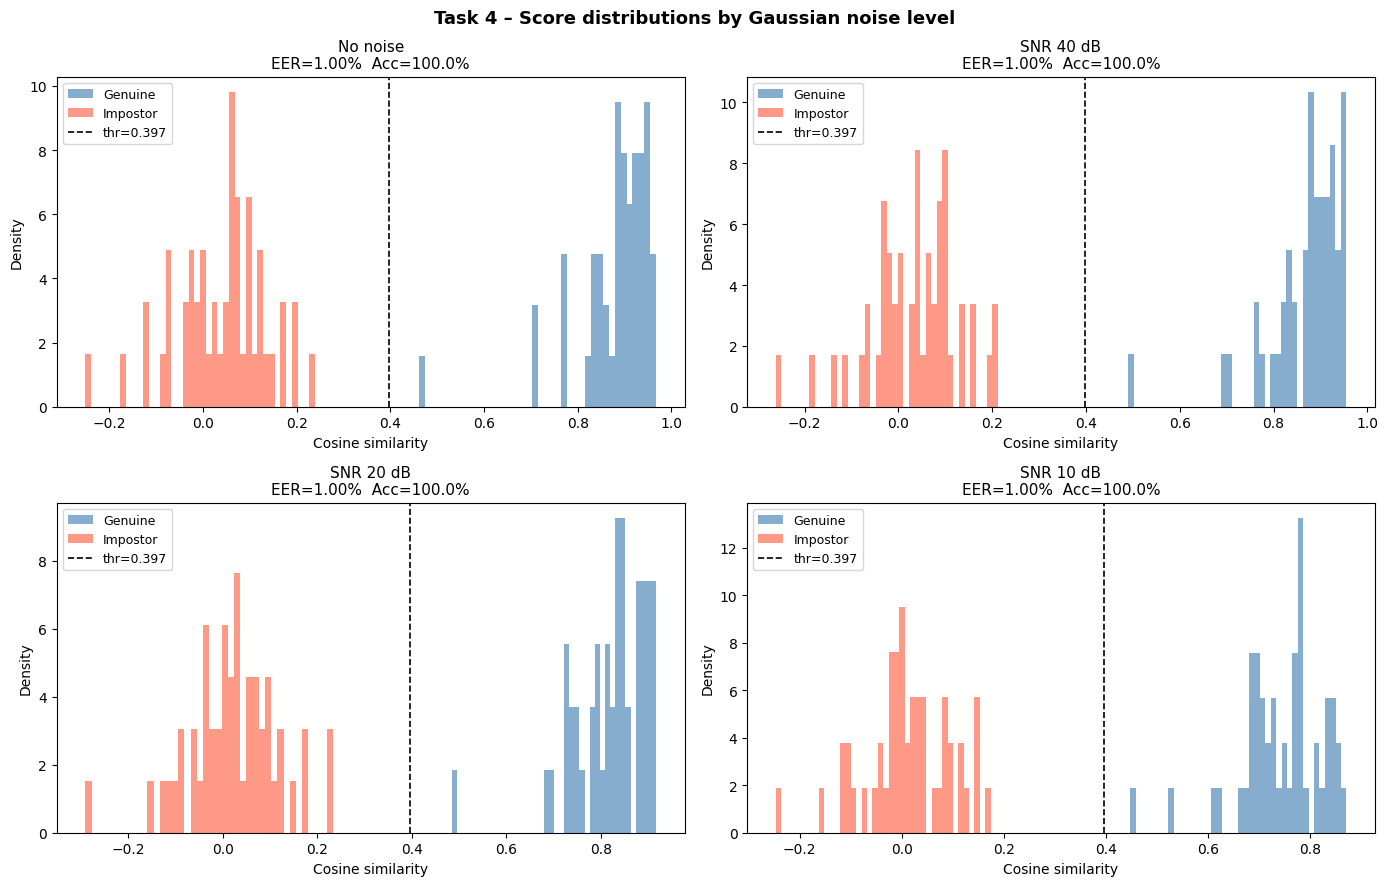

Saved: D:\pwr\biometria\lab\voice\results\task4_score_distributions.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (key, label, snr_db) in zip(axes.flat, CONDITIONS):
    gen = np.array(results[key]["genuine"])
    imp = np.array(results[key]["impostor"])

    ax.hist(gen, bins=40, alpha=0.65, color="steelblue", density=True, label="Genuine")
    ax.hist(imp, bins=40, alpha=0.65, color="tomato",    density=True, label="Impostor")
    ax.axvline(eer_threshold, color="black", linestyle="--", linewidth=1.2,
               label=f"thr={eer_threshold:.3f}")

    row_data = next((r for r in rows if r["key"] == key), None)
    if row_data:
        eer_f, _ = compute_eer(gen, imp)
        ax.set_title(
            f"{label}\nEER={eer_f*100:.2f}%  Acc={row_data['accuracy_pct']:.1f}%",
            fontsize=11,
        )
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

fig.suptitle("Task 4 – Score distributions by Gaussian noise level", fontsize=13, fontweight="bold")
fig.tight_layout()

out = RESULTS_DIR / "task4_score_distributions.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 8. Degradation curves (EER & Accuracy vs. SNR)

Shows how performance degrades as noise increases (SNR decreases).

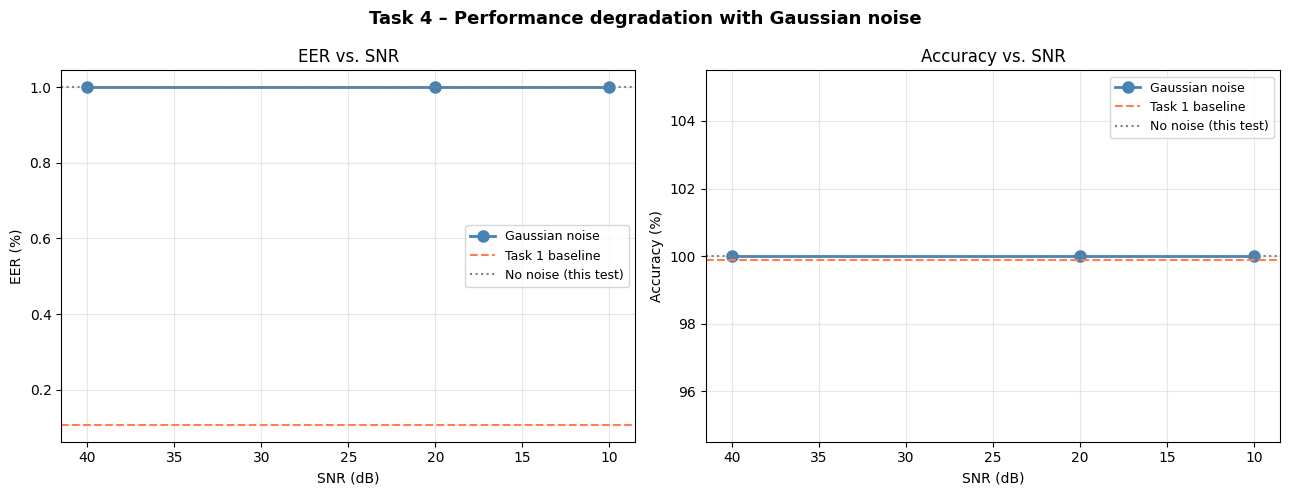

Saved: D:\pwr\biometria\lab\voice\results\task4_degradation.png


In [9]:
# Only noisy conditions (exclude no_noise)
noisy_rows = [r for r in rows if r["snr_db"] is not None]
snr_vals   = [r["snr_db"]      for r in noisy_rows]
eer_vals   = [r["eer_pct"]     for r in noisy_rows]
acc_vals   = [r["accuracy_pct"] for r in noisy_rows]

# Reference: no_noise and task1 baseline
no_noise_row = next((r for r in rows if r["snr_db"] is None), None)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, vals, ylabel, title, task1_val, no_noise_val in [
    (
        axes[0], eer_vals, "EER (%)", "EER vs. SNR",
        task1["eer_pct"],
        no_noise_row["eer_pct"] if no_noise_row else None,
    ),
    (
        axes[1], acc_vals, "Accuracy (%)", "Accuracy vs. SNR",
        task1["accuracy_at_eer_pct"],
        no_noise_row["accuracy_pct"] if no_noise_row else None,
    ),
]:
    ax.plot(snr_vals, vals, "o-", color="steelblue", linewidth=2, markersize=8, label="Gaussian noise")
    ax.axhline(task1_val, color="coral",    linestyle="--", linewidth=1.5, label="Task 1 baseline")
    if no_noise_val is not None:
        ax.axhline(no_noise_val, color="gray", linestyle=":", linewidth=1.5, label="No noise (this test)")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.invert_xaxis()  # high SNR (clean) on left, low SNR (noisy) on right
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle("Task 4 – Performance degradation with Gaussian noise", fontsize=13, fontweight="bold")
fig.tight_layout()

out = RESULTS_DIR / "task4_degradation.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 9. Comparison with Task 1

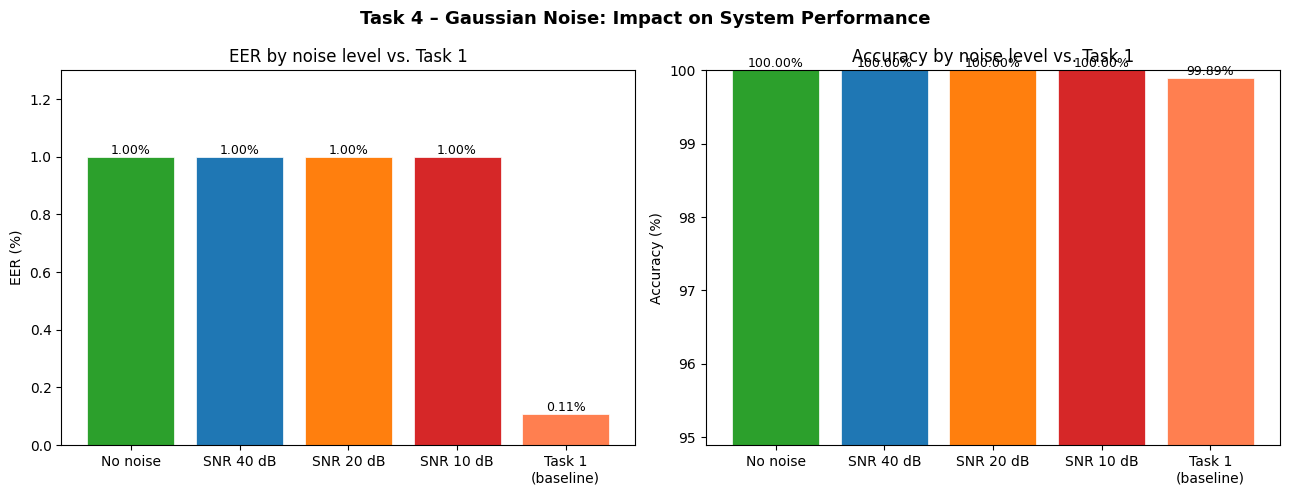

Saved: D:\pwr\biometria\lab\voice\results\task4_comparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels   = [r["label"] for r in rows] + ["Task 1\n(baseline)"]
eer_cmp  = [r["eer_pct"]      for r in rows] + [task1["eer_pct"]]
acc_cmp  = [r["accuracy_pct"] for r in rows] + [task1["accuracy_at_eer_pct"]]
colors   = ["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728", "coral"]

for ax, vals, ylabel, title in [
    (axes[0], eer_cmp,  "EER (%)",      "EER by noise level vs. Task 1"),
    (axes[1], acc_cmp,  "Accuracy (%)", "Accuracy by noise level vs. Task 1"),
]:
    bars = ax.bar(labels, vals, color=colors[:len(vals)], edgecolor="white", linewidth=0.5)
    ax.bar_label(bars, fmt="%.2f%%", fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[0].set_ylim(0, max(eer_cmp) * 1.3)
axes[1].set_ylim(max(0, min(acc_cmp) - 5), 100)

fig.suptitle("Task 4 – Gaussian Noise: Impact on System Performance", fontsize=13, fontweight="bold")
fig.tight_layout()

out = RESULTS_DIR / "task4_comparison.png"
fig.savefig(out, dpi=150)
plt.show()
print(f"Saved: {out}")

## 10. Save results

In [11]:
summary = {
    "task": 4,
    "description": "Additive white Gaussian noise at SNR 40/20/10 dB calibrated per sample",
    "n_trials": len(trials),
    "eer_threshold_used": eer_threshold,
    "per_condition": rows,
    "task1_eer_pct":      task1["eer_pct"],
    "task1_accuracy_pct": task1["accuracy_at_eer_pct"],
}

out_json = RESULTS_DIR / "task4_results.json"
with open(out_json, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "═" * 56)
print("  TASK 4 – GAUSSIAN NOISE RESULTS")
print("═" * 56)
print(f"  {'Condition':<12} {'EER%':>8} {'FAR%':>8} {'FRR%':>8} {'Acc%':>8}")
print("  " + "-" * 44)
for r in rows:
    print(
        f"  {r['label']:<12} {r['eer_pct']:>8.2f}"
        f" {r['far_pct']:>8.2f} {r['frr_pct']:>8.2f} {r['accuracy_pct']:>8.2f}"
    )
print("  " + "-" * 44)
print(
    f"  {'Baseline (T1)':<12} {task1['eer_pct']:>8.2f}"
    f" {task1['far_at_eer_pct']:>8.2f} {task1['frr_at_eer_pct']:>8.2f} {task1['accuracy_at_eer_pct']:>8.2f}"
)
print("═" * 56)
print(f"\nJSON saved: {out_json}")


════════════════════════════════════════════════════════
  TASK 4 – GAUSSIAN NOISE RESULTS
════════════════════════════════════════════════════════
  Condition        EER%     FAR%     FRR%     Acc%
  --------------------------------------------
  No noise         1.00     0.00     0.00   100.00
  SNR 40 dB        1.00     0.00     0.00   100.00
  SNR 20 dB        1.00     0.00     0.00   100.00
  SNR 10 dB        1.00     0.00     0.00   100.00
  --------------------------------------------
  Baseline (T1)     0.11     0.14     0.07    99.89
════════════════════════════════════════════════════════

JSON saved: D:\pwr\biometria\lab\voice\results\task4_results.json
